# Paper Plots - Confusion Matrices (MEL 2)

This notebook generates confusion matrix figures for MEL 2 across five indicators:
- Relevance
- Interpretation
- Completeness
- Differential Regime
- Discretion

Outputs include individual figures and one panel figure in PNG/SVG/PDF.

## 1) Imports and Style

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.titlesize": 21,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2) Configuration (Editable)

In [2]:
PROJECT_ROOT = Path.cwd()

CANDIDATE_DATA_DIRS = [
    PROJECT_ROOT / "MEL 2",
    PROJECT_ROOT / "Version 2" / "MEL 2",
    PROJECT_ROOT.parent / "Version 2" / "MEL 2",
]

DATA_DIR = next((path.resolve() for path in CANDIDATE_DATA_DIRS if path.exists()), CANDIDATE_DATA_DIRS[0].resolve())
OUTPUT_DIR = DATA_DIR.parent / "paper_figures" / "confmat_mel2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORDERED_FILES = [
    "confmat_mel__Relevance.csv",
    "confmat_mel__Interpretability.csv",
    "confmat_mel__Completeness.csv",
    "confmat_mel__Differential_Regime.csv",
    "confmat_mel__Discretionality.csv",
]

TITLE_PREFIX = {
    "Relevance": "a",
    "Interpretability": "b",
    "Completeness": "c",
    "Differential Regime": "d",
    "Discretionality": "e",
}

DISPLAY_NAME = {
    "Interpretability": "Interpretation",
    "Discretionality": "Discretion",
}

GREEN = "#1B9E77"
CMAP = LinearSegmentedColormap.from_list("paper_green", ["#F5FBF7", GREEN])

FIGSIZE_SINGLE = (5.8, 5.2)
FIGSIZE_PANEL = (12.8, 8.6)
TITLE_FONT_SIZE = 20
TICK_LABEL_SIZE = 13
ANNOT_FONT_SIZE = 16
EXPORT_DPI = 400

print("CWD:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

CWD: c:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2
DATA_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\MEL 2
OUTPUT_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\confmat_mel2


## 3) Utility Functions

In [3]:
def resolve_confmat_file(file_name: str) -> Path:
    candidates = [
        DATA_DIR / file_name,
        PROJECT_ROOT / file_name,
        PROJECT_ROOT / "MEL 2" / file_name,
        PROJECT_ROOT / "Version 2" / "MEL 2" / file_name,
        PROJECT_ROOT.parent / "Version 2" / "MEL 2" / file_name,
    ]

    seen = set()
    ordered = []
    for c in candidates:
        key = str(c)
        if key not in seen:
            seen.add(key)
            ordered.append(c)

    for c in ordered:
        if c.exists():
            return c.resolve()

    tried = "\n- ".join(str(c) for c in ordered)
    raise FileNotFoundError(f"Missing file: {file_name}\nTried:\n- {tried}")


def build_meta(file_name: str) -> dict:
    raw = file_name.replace("confmat_mel__", "").replace(".csv", "")
    target_name = raw.replace("_", " ")

    if target_name == "Differential Regime":
        target_name = "Differential Regime"

    if target_name == "Interpretability":
        class_order = ["1", "2", "3"]
        tick_labels = ["Low (1)", "Medium (2)", "High (3)"]
    else:
        class_order = ["0", "1"]
        tick_labels = ["False", "True"]

    return {
        "file_name": file_name,
        "raw_name": raw,
        "target_name": target_name,
        "class_order": class_order,
        "tick_labels": tick_labels,
        "base_stem": f"paper_confmat_mel2__{raw}",
    }


def format_title(target_name: str) -> str:
    shown = DISPLAY_NAME.get(target_name, target_name)
    prefix = TITLE_PREFIX.get(target_name)
    return f"{prefix}) {shown}" if prefix else shown


def load_confmat(meta: dict) -> pd.DataFrame:
    path = resolve_confmat_file(meta["file_name"])
    df = pd.read_csv(path).copy()

    first_col = df.columns[0]
    df = df.rename(columns={first_col: "true_label"}).set_index("true_label")

    # Ensure numeric matrix
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df.index = df.index.map(lambda x: str(int(x)) if pd.notna(x) else str(x))
    df.columns = [str(int(float(c))) if str(c).replace(".", "", 1).isdigit() else str(c) for c in df.columns]

    order = meta["class_order"]
    for lbl in order:
        if lbl not in df.index:
            df.loc[lbl] = 0
        if lbl not in df.columns:
            df[lbl] = 0

    df = df.reindex(index=order, columns=order).fillna(0)
    return df


def save_figure(fig: plt.Figure, stem: str) -> tuple[Path, Path, Path]:
    png = OUTPUT_DIR / f"{stem}.png"
    svg = OUTPUT_DIR / f"{stem}.svg"
    pdf = OUTPUT_DIR / f"{stem}.pdf"

    fig.savefig(png, dpi=EXPORT_DPI, bbox_inches="tight")
    fig.savefig(svg, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    return png, svg, pdf


def plot_confmat(ax: plt.Axes, mat: pd.DataFrame, meta: dict, vmin: int, vmax: int, show_title: bool = True, show_cbar: bool = True):
    hm = sns.heatmap(
        mat,
        ax=ax,
        cmap=CMAP,
        annot=True,
        fmt=".0f",
        linewidths=1.0,
        linecolor="white",
        cbar=show_cbar,
        vmin=vmin,
        vmax=vmax,
        annot_kws={"size": ANNOT_FONT_SIZE, "weight": "semibold"},
        square=True,
    )

    # No axis names per paper requirement
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xticklabels(meta["tick_labels"], rotation=0, fontsize=TICK_LABEL_SIZE)
    ax.set_yticklabels(meta["tick_labels"], rotation=0, fontsize=TICK_LABEL_SIZE)
    ax.tick_params(length=0)

    if show_title:
        ax.set_title(format_title(meta["target_name"]), fontsize=TITLE_FONT_SIZE, pad=10)

    return hm

## 4) Individual Confusion Matrices

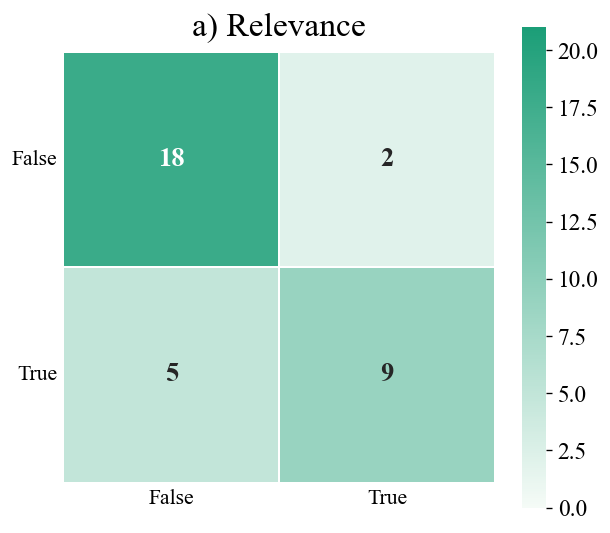

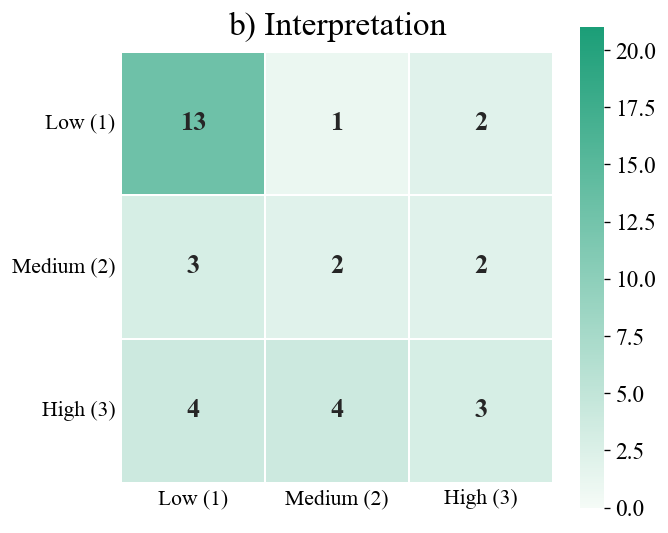

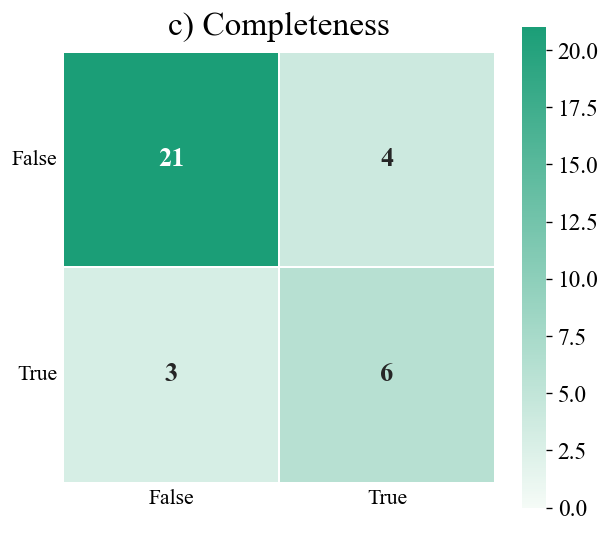

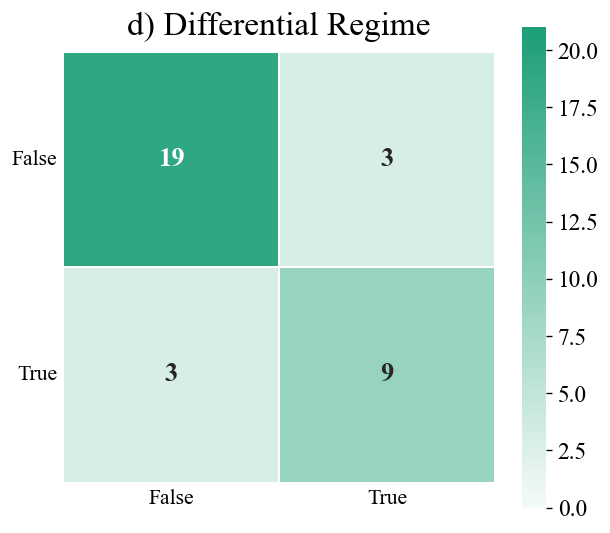

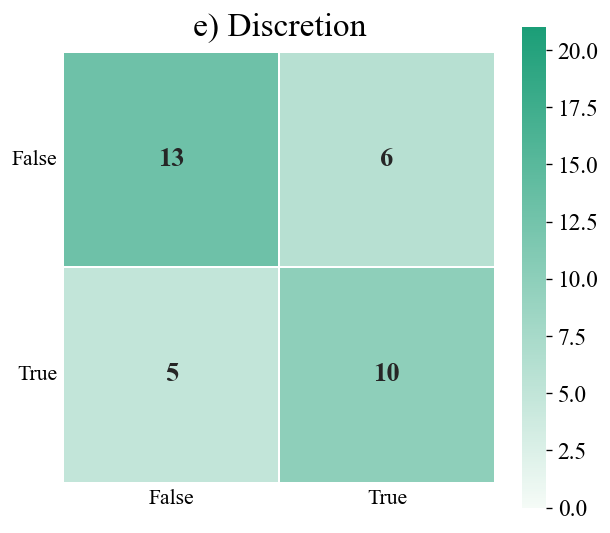

,target,display_target,png,svg,pdf
0,Relevance,Relevance,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
1,Interpretability,Interpretation,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
2,Completeness,Completeness,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
3,Differential Regime,Differential Regime,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
4,Discretionality,Discretion,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...


In [4]:
metas = [build_meta(f) for f in ORDERED_FILES]
mats = {m['target_name']: load_confmat(m) for m in metas}

global_max = int(max(mat.to_numpy().max() for mat in mats.values()))
global_min = 0

export_rows = []
for meta in metas:
    mat = mats[meta['target_name']]

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
    plot_confmat(ax, mat, meta, vmin=global_min, vmax=global_max, show_title=True, show_cbar=True)

    png, svg, pdf = save_figure(fig, meta['base_stem'])
    plt.show()
    plt.close(fig)

    export_rows.append({
        'target': meta['target_name'],
        'display_target': DISPLAY_NAME.get(meta['target_name'], meta['target_name']),
        'png': str(png),
        'svg': str(svg),
        'pdf': str(pdf),
    })

confmat_export_log = pd.DataFrame(export_rows)
confmat_export_log

## 5) Panel Figure (5 Indicators)

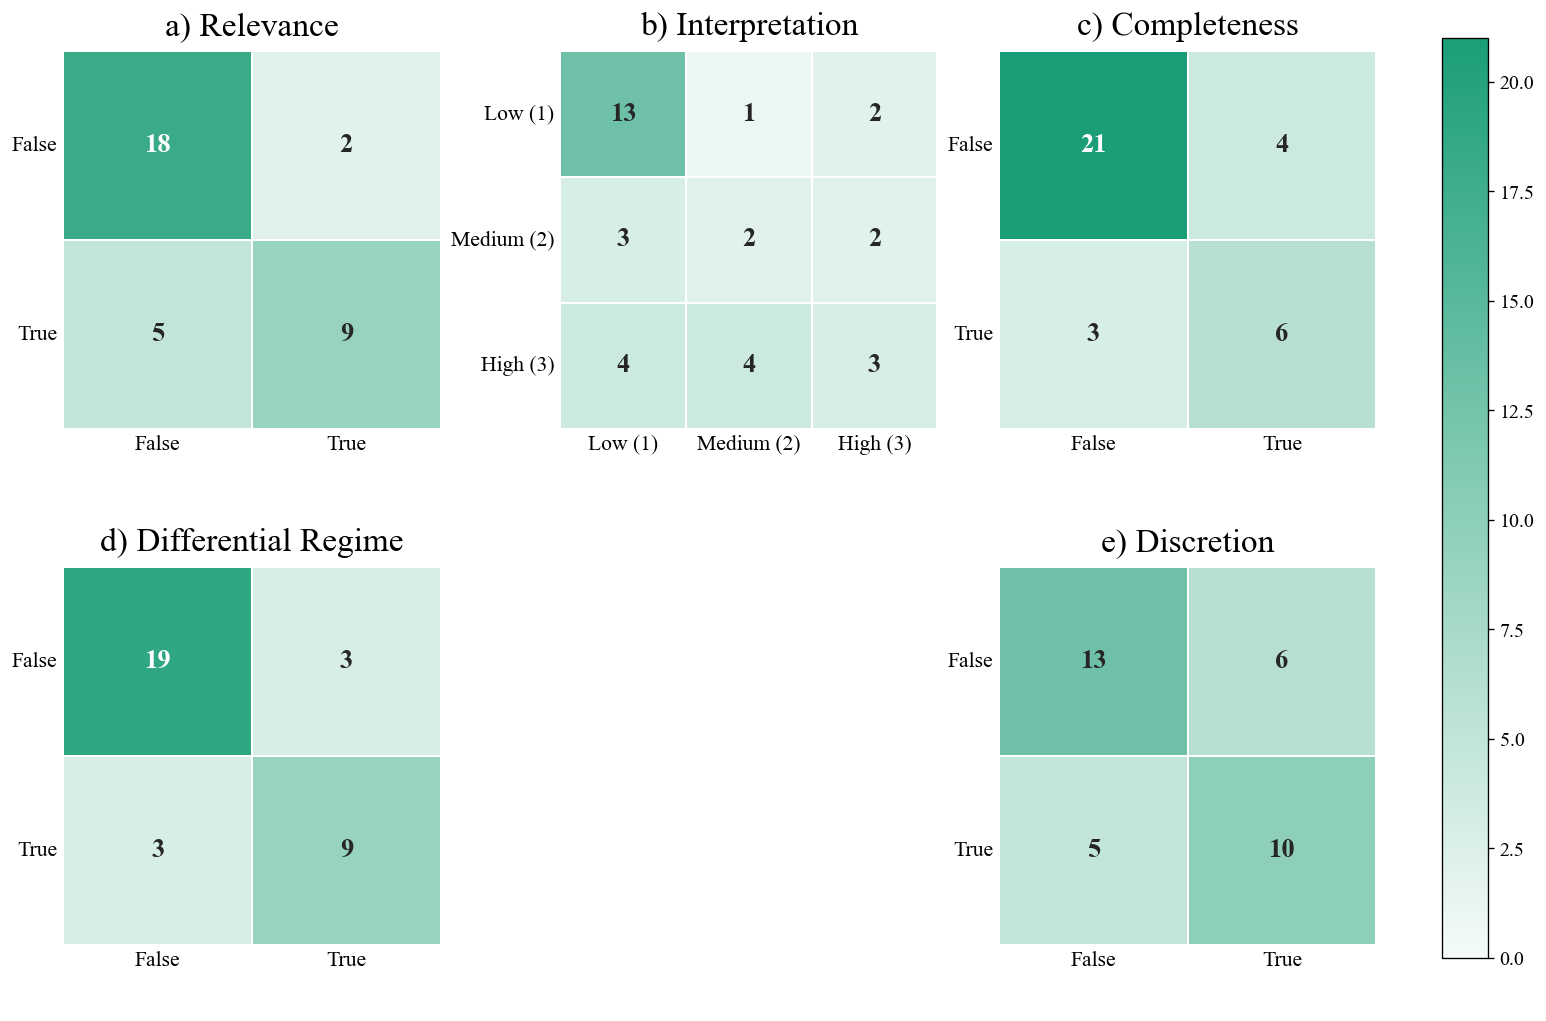

Saved panel:
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\confmat_mel2\paper_confmat_mel2__panel_5_indicators.png
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\confmat_mel2\paper_confmat_mel2__panel_5_indicators.svg
- C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\confmat_mel2\paper_confmat_mel2__panel_5_indicators.pdf


In [5]:
fig, axes = plt.subplots(2, 3, figsize=FIGSIZE_PANEL, constrained_layout=True)
axes = axes.flatten()

# Layout: top row full, bottom middle empty
slot_map = [0, 1, 2, 3, 5]
heatmap_artist = None

for meta, slot in zip(metas, slot_map):
    mat = mats[meta['target_name']]
    hm = plot_confmat(axes[slot], mat, meta, vmin=global_min, vmax=global_max, show_title=True, show_cbar=False)
    if heatmap_artist is None:
        heatmap_artist = hm.collections[0]

axes[4].axis('off')

# Single shared colorbar for the panel
if heatmap_artist is not None:
    cbar = fig.colorbar(heatmap_artist, ax=[axes[i] for i in [0, 1, 2, 3, 5]], shrink=0.9, location='right')
    cbar.ax.tick_params(labelsize=12)

panel_png, panel_svg, panel_pdf = save_figure(fig, 'paper_confmat_mel2__panel_5_indicators')
plt.show()
plt.close(fig)

print('Saved panel:')
print('-', panel_png)
print('-', panel_svg)
print('-', panel_pdf)

## 6) Reproducibility Log

In [6]:
log = confmat_export_log.copy()
log['source_file'] = [m['file_name'] for m in metas]
log['source_path'] = log['source_file'].apply(lambda x: str(resolve_confmat_file(x)))

log_path = OUTPUT_DIR / 'paper_confmat_mel2_export_log.csv'
log.to_csv(log_path, index=False)

print('Saved reproducibility log:', log_path)
log

Saved reproducibility log: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\confmat_mel2\paper_confmat_mel2_export_log.csv


,target,display_target,png,svg,pdf,source_file,source_path
0,Relevance,Relevance,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,confmat_mel__Relevance.csv,C:\Users\57305\OneDrive - Universidad Nacional...
1,Interpretability,Interpretation,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,confmat_mel__Interpretability.csv,C:\Users\57305\OneDrive - Universidad Nacional...
2,Completeness,Completeness,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,confmat_mel__Completeness.csv,C:\Users\57305\OneDrive - Universidad Nacional...
3,Differential Regime,Differential Regime,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,confmat_mel__Differential_Regime.csv,C:\Users\57305\OneDrive - Universidad Nacional...
4,Discretionality,Discretion,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,confmat_mel__Discretionality.csv,C:\Users\57305\OneDrive - Universidad Nacional...
